# Calculate Trends at open-vsx.org
This Jupyter notebook calculates graphs over time at open-vsx.org; publishers, extensions, downloads. To use, you need admin authority and a personal access token from https://open-vsx.org/user-settings/tokens.

In [1]:
import matplotlib.pyplot as plt
import os

os.environ["ACCESS_TOKEN"] = "****"
os.environ["API_ENDPOINT"] = "https://open-vsx.org/"

import get_open_vsx_data

STARTING_YEAR = 2021
STARTING_MONTH = 11

df = get_open_vsx_data.get_publishing_data(STARTING_YEAR, STARTING_MONTH)

processed results for 2021-11
processed results for 2021-12
processed results for 2022-1
processed results for 2022-2
processed results for 2022-3
processed results for 2022-4
processed results for 2022-5
processed results for 2022-6
processed results for 2022-7
processed results for 2022-8
processed results for 2022-9
processed results for 2022-10
processed results for 2022-11
processed results for 2022-12
processed results for 2023-1
processed results for 2023-2
processed results for 2023-3
processed results for 2023-4
processed results for 2023-5
processed results for 2023-6
processed results for 2023-7
processed results for 2023-8
processed results for 2023-9
Error decoding JSON results for https://open-vsx.org/admin/report?year=2023&month=10&token=39a9d6a4-9dc3-4fda-89b5-743d33ce0b0a
Error decoding JSON results for https://open-vsx.org/admin/report?year=2023&month=11&token=39a9d6a4-9dc3-4fda-89b5-743d33ce0b0a
processed results for 2023-12
processed results for 2024-1
processed res

In [2]:
df

,year,month,extensions,downloads,downloadsTotal,publishers,averageReviewsPerExtension,namespaceOwners
0,2021,11,1463,9331477,9331477,629,1.232044,517
1,2021,12,1510,612385,9943862,661,1.245989,536
2,2022,1,1560,460924,10404786,704,1.258706,568
3,2022,2,1608,978755,11383541,736,1.274038,594
4,2022,3,1672,423839,11807380,779,1.312217,625
5,2022,4,1746,727235,12534615,813,1.304721,651
6,2022,5,1817,440826,12975441,858,1.301255,679
7,2022,6,1920,774739,13750180,920,1.307985,731
8,2022,7,1994,855466,14605646,959,1.304348,759
9,2022,8,2062,1036620,15642266,999,1.310345,795


In [3]:
dates = []
index = 0
for year in df['year']:
    dates.append("%s/%s" % (df['month'][index], str(year)[2:]))
    index += 1
df['date'] = dates

In [4]:
downloads_graph = []
for total in df['downloadsTotal']:
    downloads_graph.append(total / 1000000)
df['downloads_graph'] = downloads_graph

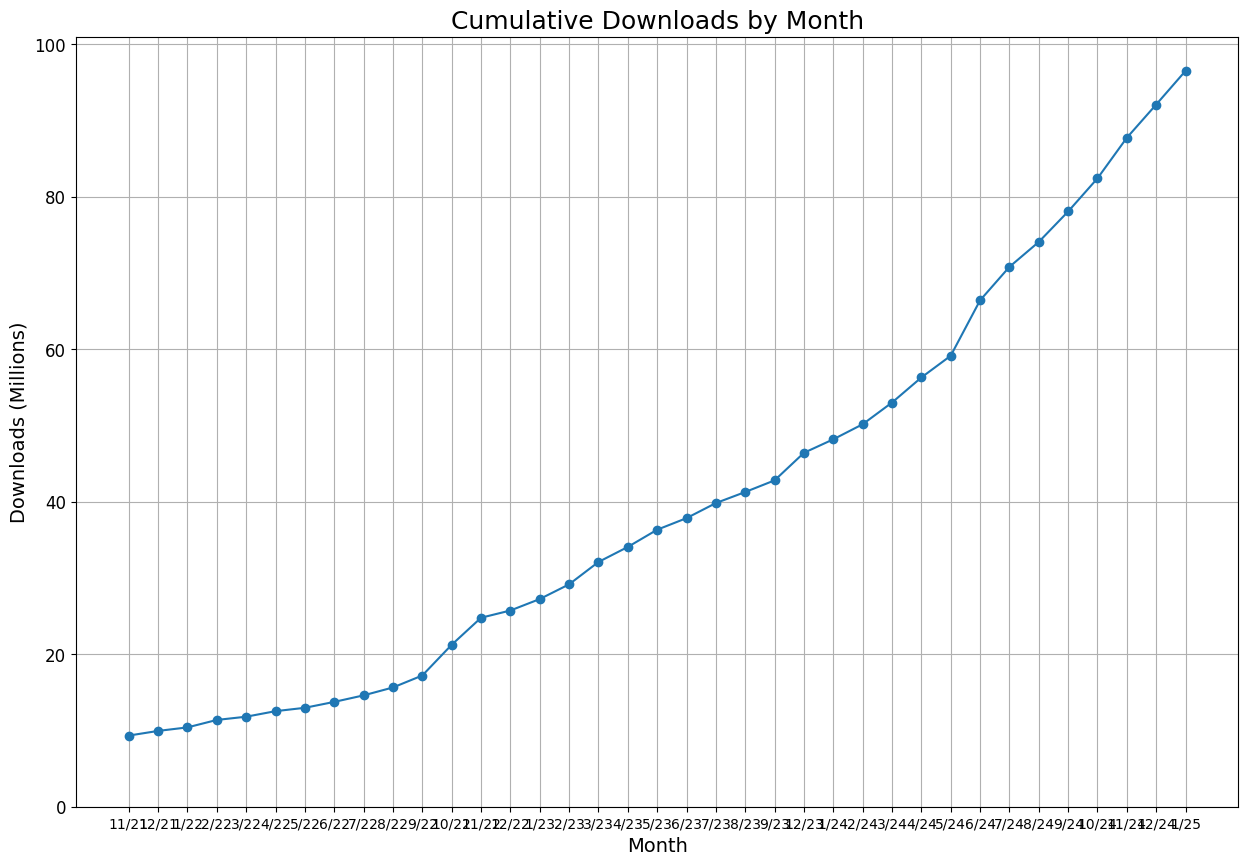

,year,month,extensions,downloads,downloadsTotal,publishers,averageReviewsPerExtension,namespaceOwners,date,downloads_graph
0,2021,11,1463,9331477,9331477,629,1.232044,517,11/21,9.331477
1,2021,12,1510,612385,9943862,661,1.245989,536,12/21,9.943862
2,2022,1,1560,460924,10404786,704,1.258706,568,1/22,10.404786
3,2022,2,1608,978755,11383541,736,1.274038,594,2/22,11.383541
4,2022,3,1672,423839,11807380,779,1.312217,625,3/22,11.807380
5,2022,4,1746,727235,12534615,813,1.304721,651,4/22,12.534615
6,2022,5,1817,440826,12975441,858,1.301255,679,5/22,12.975441
7,2022,6,1920,774739,13750180,920,1.307985,731,6/22,13.750180
8,2022,7,1994,855466,14605646,959,1.304348,759,7/22,14.605646
9,2022,8,2062,1036620,15642266,999,1.310345,795,8/22,15.642266


In [8]:
y_max = df['downloads_graph'][len(df['downloads_graph'])-1]
y_axis_max = int(y_max) + 5
plt.ylim([0, y_axis_max])
# plt.style.use('seaborn-dark')
plt.rcParams["figure.figsize"] = (15,10)
plt.grid(True)
plt.plot(df['date'], df['downloads_graph'], marker='o')
plt.title('Cumulative Downloads by Month', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Downloads (Millions)', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=12)
plt.show()
df

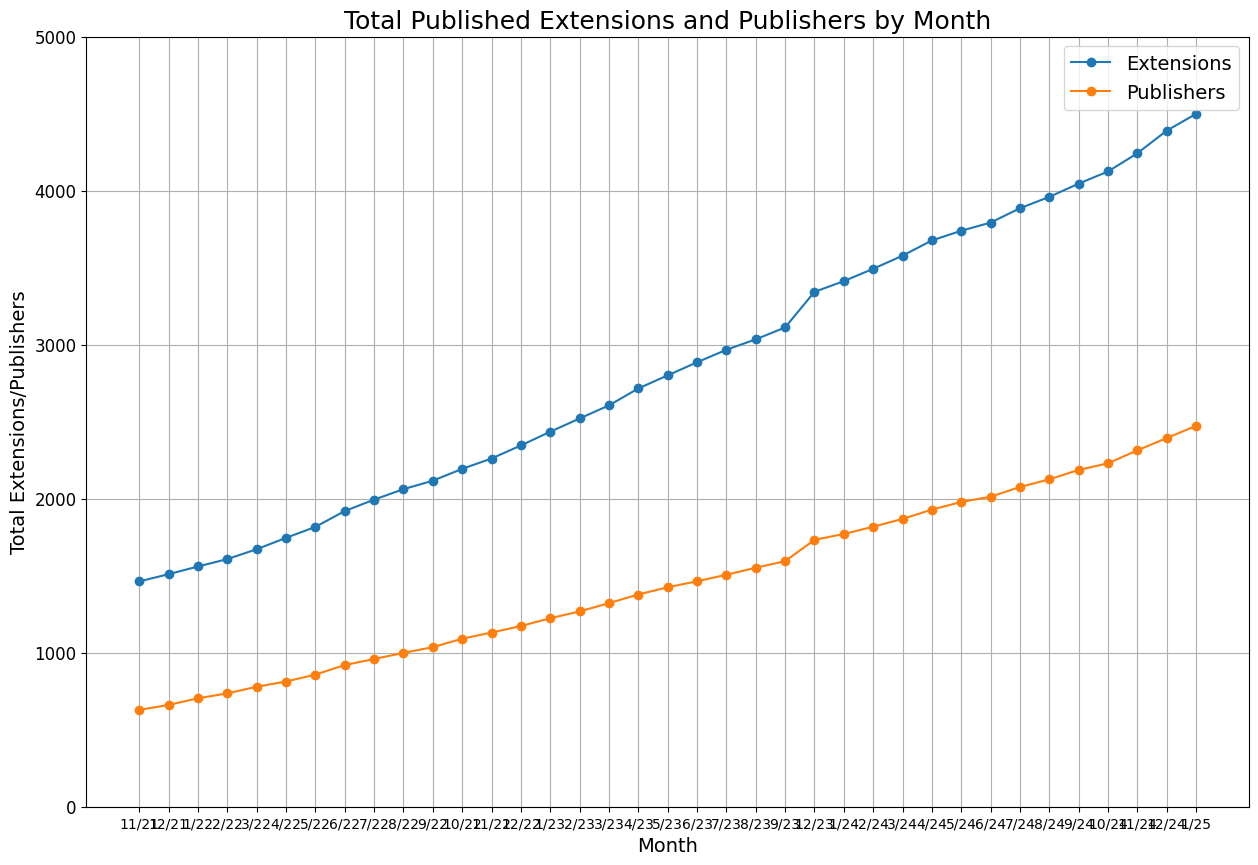

In [6]:
y_max = df['extensions'][len(df['extensions'])-1]
y_axis_max = (int(y_max / 1000) + 1) * 1000
plt.ylim([0, y_axis_max])
# plt.style.use('seaborn-dark')
plt.rcParams["figure.figsize"] = (15,10)
plt.grid(True)
plt.plot(df['date'], df['extensions'], marker='o', label='Extensions')
plt.plot(df['date'], df['publishers'], marker='o', label='Publishers')
plt.title('Total Published Extensions and Publishers by Month', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.xticks(fontsize=10)
plt.ylabel('Total Extensions/Publishers', fontsize=14)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()

In [7]:
df

,year,month,extensions,downloads,downloadsTotal,publishers,averageReviewsPerExtension,namespaceOwners,date,downloads_graph
0,2021,11,1463,9331477,9331477,629,1.232044,517,11/21,9.331477
1,2021,12,1510,612385,9943862,661,1.245989,536,12/21,9.943862
2,2022,1,1560,460924,10404786,704,1.258706,568,1/22,10.404786
3,2022,2,1608,978755,11383541,736,1.274038,594,2/22,11.383541
4,2022,3,1672,423839,11807380,779,1.312217,625,3/22,11.807380
5,2022,4,1746,727235,12534615,813,1.304721,651,4/22,12.534615
6,2022,5,1817,440826,12975441,858,1.301255,679,5/22,12.975441
7,2022,6,1920,774739,13750180,920,1.307985,731,6/22,13.750180
8,2022,7,1994,855466,14605646,959,1.304348,759,7/22,14.605646
9,2022,8,2062,1036620,15642266,999,1.310345,795,8/22,15.642266
